In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, confusion_matrix, classification_report

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.cluster import AgglomerativeClustering

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler, MinMaxScaler

import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
def rate_classifier(test_target_data, test_target_predict):
    cm = confusion_matrix(test_target_data, test_target_predict)

    terminology = ['True Negative', 'False Positive', 'False Negative', 'True Positive']
    counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    percentages = ["{0:0.2%}".format(value) for value in cm.flatten()/np.sum(cm)]
    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(terminology, counts, percentages)]
    labels = np.asarray(labels).reshape(2,2)

    plt.figure(figsize=(10,7))
    sb.heatmap(cm/np.sum(cm), annot=labels, fmt='', cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Truth')

    print("Classification Report\n", classification_report(test_target_data, test_target_predict))

    print("Accuracy Score\n", accuracy_score(test_target_data, test_target_predict))

In [3]:
df = pd.read_csv('../Data/creditcard.csv')

In [4]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## No Null Values in the dataset

In [6]:
print(df.isna().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


## All features besides Time, Amount, and the target variable Class are PCA transformed. The oriinal features are hidden due to confidentiality issues. 
* The feature Time is the seconds elapsed between each transaction and the first transaction in the dataset.
* The feature Amount is the transaction amount, this  feature can be used for example-dependant cost-sensitive learning.
* The feature Class is the response variable and is either 1 in case of fraud or 0 otherwise.
* Given the class imbalance ratio we recommend measuring the accuracy using the Area Under the Precision-Recall Curve (AUPRC)
    * Consfusion matrix accuracy is not meaningful for unbalanced classification.

Average Amount spent varies, the Fraud amount average is approximately 38% larger

In [7]:
122.21/88.29

1.384188469815381

In [8]:
df.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


In [9]:
df['Amount'].mean()

88.34961925087359

No Negative values, nobody tried to return something to increase credit available on card.

In [10]:
print([x for x in df['Amount'] if x < 0])

[]


In [11]:
print(len([x for x in df['Amount'] if x == 0]))

1825


In [12]:
fraud_zero_spent = df[(df['Amount'] == 0) & (df['Class'] == 1)]
fraud_zero_spent.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.0,1
8842,12093.0,-4.696795,2.693867,-4.475133,5.467685,-1.556758,-1.549420,-4.104215,0.553934,-1.498468,...,0.573898,-0.080163,0.318408,-0.245862,0.338238,0.032271,-1.508458,0.608075,0.0,1
23308,32686.0,0.287953,1.728735,-1.652173,3.813544,-1.090927,-0.984745,-2.202318,0.555088,-2.033892,...,0.262202,-0.633528,0.092891,0.187613,0.368708,-0.132474,0.576561,0.309843,0.0,1
42756,41233.0,-10.645800,5.918307,-11.671043,8.807369,-7.975501,-3.586806,-13.616797,6.428169,-7.368451,...,2.571970,0.206809,-1.667801,0.558419,-0.027898,0.354254,0.273329,-0.152908,0.0,1
69980,53658.0,-1.739341,1.344521,-0.534379,3.195291,-0.416196,-1.261961,-2.340991,0.713004,-1.416265,...,0.383180,-0.213952,-0.336640,0.237076,0.246003,-0.044228,0.510729,0.220952,0.0,1


In [13]:
class_imbalance_percent = (df[df['Class'] == 1].shape[0] / df.shape[0]) * 100

In [14]:
class_imbalance_percent

0.1727485630620034

## Splitting Data

In [15]:
decision_features = df.columns[:-1]
target_feature = df.columns[-1]

In [16]:
X = df[decision_features]
y = df[target_feature]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=999)
## 0.8 x 0.25 = 0.2
# X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=999)

## Testing Different Classification models as Baseline

### K-Nearest Neighbors

In [18]:
standard_scaler = StandardScaler()

In [19]:
scaled_X = standard_scaler.fit_transform(X, y)

In [20]:
scaled_X_train, scaled_X_test, scaled_y_train, scaled_y_test = train_test_split(scaled_X, y, test_size=0.2, random_state=999)
## 0.8 x 0.25 = 0.2
# scaled_X_train, scaled_X_val, scaled_y_train, scaled_y_val = train_test_split(scaled_X_train, scaled_y_train, test_size=0.25, random_state=999)

In [21]:
def best_k_value(X, y):
    k_values = list(range(1, 50))

    # Create an empty list to store the cross-validation scores
    cv_scores = []
    cv_means = []
    cv_stds = []


    # Loop over the possible K values and compute the cross-validation score for each one
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
        cv_scores.append(scores)
        cv_means.append(scores.mean())
        cv_stds.append(scores.std())

    # Determine the best value of K
    best_k = k_values[np.argmax(cv_means)]

    plt.errorbar(k_values, cv_means, yerr=cv_stds, fmt='o')
    plt.xlabel('K-Value')
    plt.ylabel('Cross Validation Accuracy')
    plt.show()
    
    print(f'   Mean: {np.max(cv_means)}')
    print(f'   Standard Deviation: {cv_stds[np.argmax(cv_means)]}')
    print(f'The optimal K value = {best_k}')

    return {'best_k': best_k, 'cv_scores': cv_scores, 'cv_means': cv_means, 'cv_stds': cv_stds}

In [22]:
#best_k_dict = best_k_value(scaled_X_train, scaled_y_train)

best_k for Standard Scaled data = 3

#### "Best"-K value
* K = 2 for unscaled Data, with 3 very close behind (took 22 Minutes)
* K = 3 for Standard Scaler (took 20 Minutes)
* K = _ for MinMaxScaler

In [23]:
knn_3n = KNeighborsClassifier(n_neighbors = 3)

In [24]:
knn3n = knn_3n.fit(scaled_X_train, scaled_y_train)

In [25]:
knn_3n_def_pred = knn_3n.predict(scaled_X_test)

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56876
           1       0.94      0.87      0.90        86

    accuracy                           1.00     56962
   macro avg       0.97      0.94      0.95     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy Score
 0.9997191109862715


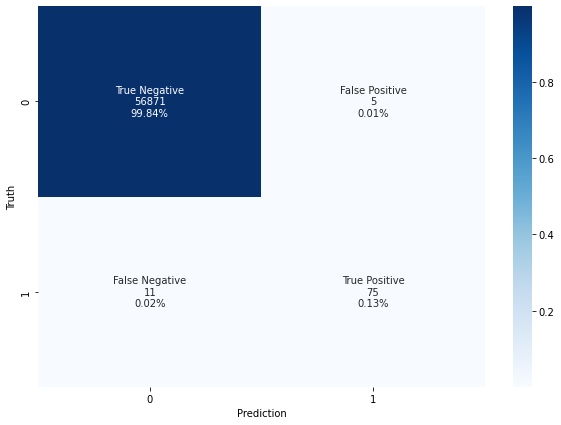

In [26]:
rate_classifier(scaled_y_test, knn_3n_def_pred)

### SVM

#### Default SVC

In [27]:
svm = SVC()

In [28]:
svm = svm.fit(scaled_X_train, scaled_y_train)

In [29]:
svm_pred = svm.predict(scaled_X_test)

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56876
           1       0.94      0.74      0.83        86

    accuracy                           1.00     56962
   macro avg       0.97      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy Score
 0.9995435553526912


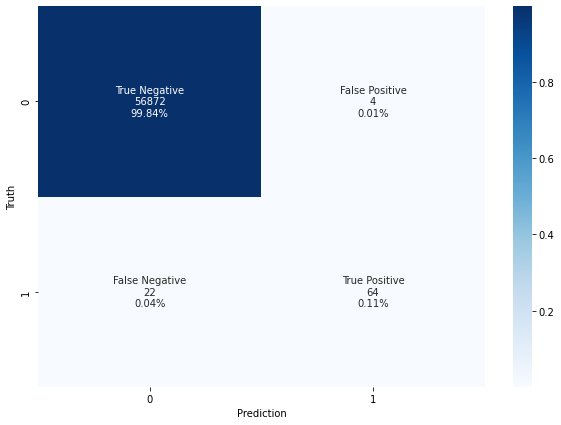

In [30]:
rate_classifier(scaled_y_test, svm_pred)

#### C-Adjusted SVC

In [31]:
c_svm = SVC(C=100)

In [32]:
c_svm = c_svm.fit(scaled_X_train, scaled_y_train)

In [33]:
c_svm_pred = c_svm.predict(scaled_X_test)

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56876
           1       0.84      0.80      0.82        86

    accuracy                           1.00     56962
   macro avg       0.92      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy Score
 0.9994733330992591


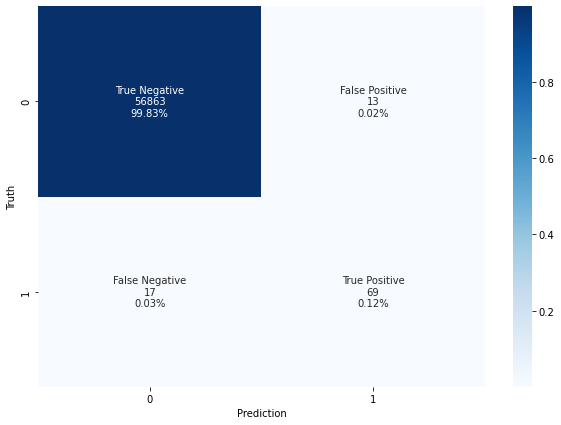

In [34]:
rate_classifier(scaled_y_test, c_svm_pred)

### Naive Bayes

#### Gaussian

In [35]:
gaussian_nb = GaussianNB()

In [36]:
gaussian_nb = gaussian_nb.fit(X_train, y_train)

In [37]:
gaussian_nb_pred = gaussian_nb.predict(X_test)

Classification Report
               precision    recall  f1-score   support

           0       1.00      0.99      1.00     56876
           1       0.14      0.71      0.24        86

    accuracy                           0.99     56962
   macro avg       0.57      0.85      0.62     56962
weighted avg       1.00      0.99      1.00     56962

Accuracy Score
 0.9931884414170851


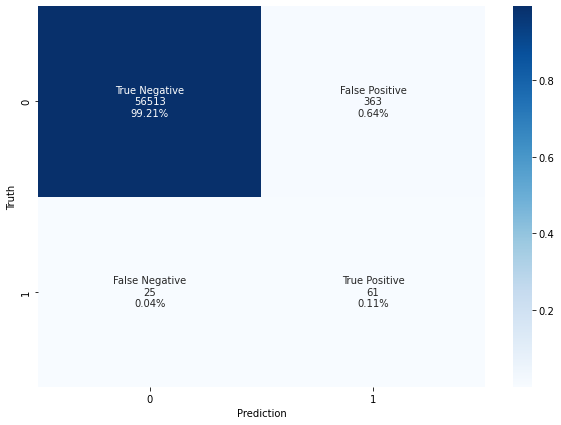

In [38]:
rate_classifier(y_test, gaussian_nb_pred)

#### Bernoulli

In [39]:
bernoulli_nb = BernoulliNB()

In [40]:
bernoulli_nb = bernoulli_nb.fit(X_train, y_train)

In [41]:
bernoulli_nb_pred = bernoulli_nb.predict(X_test)

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56876
           1       0.89      0.64      0.74        86

    accuracy                           1.00     56962
   macro avg       0.94      0.82      0.87     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy Score
 0.9993328885923949


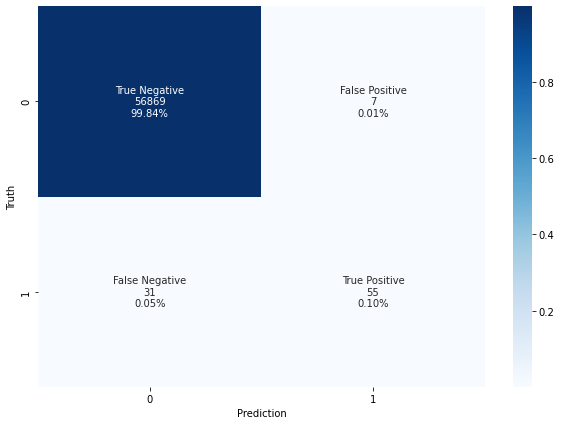

In [42]:
rate_classifier(y_test, bernoulli_nb_pred)

### Logistic Regression

In [43]:
log_regressor = LogisticRegression()

In [44]:
log_regressor = log_regressor.fit(scaled_X_train, scaled_y_train)

In [45]:
log_regressor_pred = log_regressor.predict(scaled_X_test)

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56876
           1       0.95      0.64      0.76        86

    accuracy                           1.00     56962
   macro avg       0.97      0.82      0.88     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy Score
 0.999403110845827


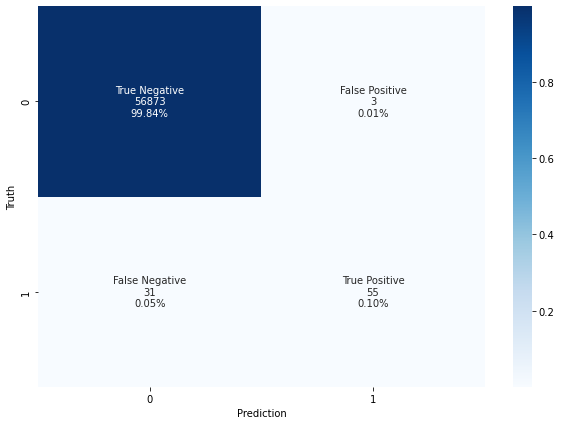

In [46]:
rate_classifier(scaled_y_test, log_regressor_pred)

### Gradient Descent Classifier

In [47]:
grad_desc_classifier = SGDClassifier()

In [48]:
grad_desc_classifier = grad_desc_classifier.fit(scaled_X_train, scaled_y_train)

In [49]:
grad_desc_classifier_pred = grad_desc_classifier.predict(scaled_X_test)

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56876
           1       0.96      0.59      0.73        86

    accuracy                           1.00     56962
   macro avg       0.98      0.80      0.87     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy Score
 0.9993504441557529


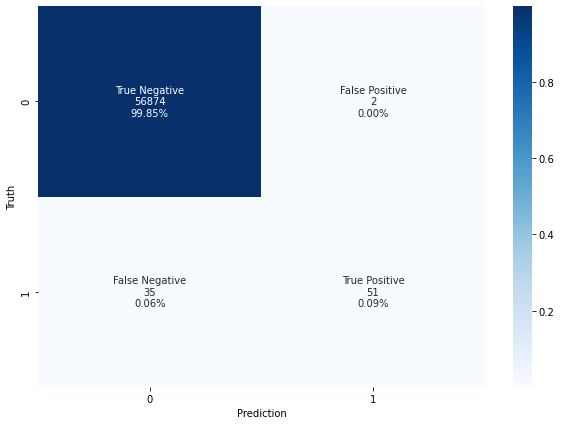

In [50]:
rate_classifier(scaled_y_test, grad_desc_classifier_pred)

### Ensemble Models

#### Default Random Forest

In [51]:
def_random_forest = RandomForestClassifier()

In [52]:
def_random_forest = def_random_forest.fit(X_train, y_train)

KeyboardInterrupt: 

In [ ]:
def_random_forest_pred = def_random_forest.predict(X_test)

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56876
           1       0.97      0.85      0.91        86

    accuracy                           1.00     56962
   macro avg       0.99      0.92      0.95     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy Score
 0.9997366665496296


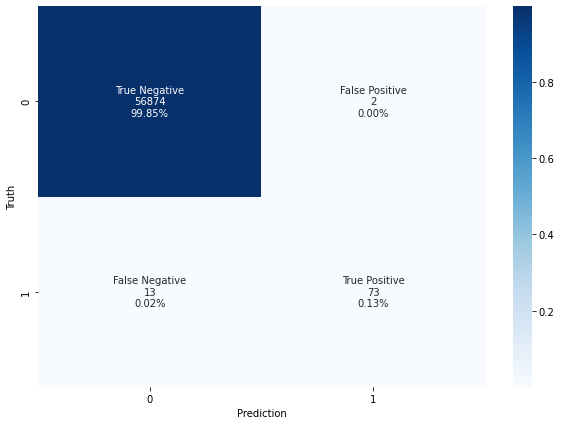

In [ ]:
rate_classifier(y_test, def_random_forest_pred)

#### Default AdaBoost

In [ ]:
def_ada_boost = AdaBoostClassifier()

In [ ]:
def_ada_boost = def_ada_boost.fit(X_train, y_train)

In [ ]:
def_ada_boost_pred = def_ada_boost.predict(X_test)

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56876
           1       0.85      0.71      0.77        86

    accuracy                           1.00     56962
   macro avg       0.92      0.85      0.89     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy Score
 0.9993679997191109


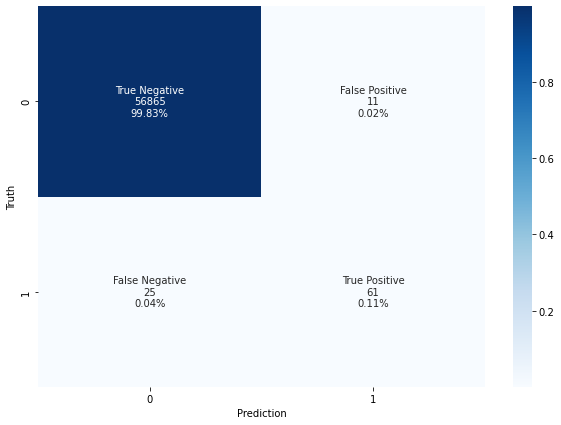

In [ ]:
rate_classifier(y_test, def_ada_boost_pred)

### Multi-Layer Perceptron

#### Non-Scaled Data

In [ ]:
mlp = MLPClassifier()

In [ ]:
mlp = mlp.fit(X_train, y_train)

In [ ]:
mlp_pred = mlp.predict(X_test)

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56876
           1       0.80      0.05      0.09        86

    accuracy                           1.00     56962
   macro avg       0.90      0.52      0.54     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy Score
 0.9985428882412837


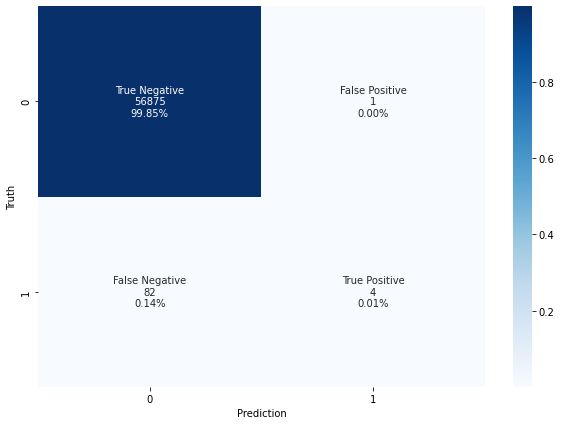

In [ ]:
rate_classifier(y_test, mlp_pred)

#### Standard Scaled

In [ ]:
scaled_mlp = MLPClassifier()

In [ ]:
scaled_mlp = scaled_mlp.fit(scaled_X_train, scaled_y_train)

In [ ]:
scaled_mlp_pred = scaled_mlp.predict(scaled_X_test)

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56876
           1       0.87      0.87      0.87        86

    accuracy                           1.00     56962
   macro avg       0.94      0.94      0.94     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy Score
 0.9996137776061234


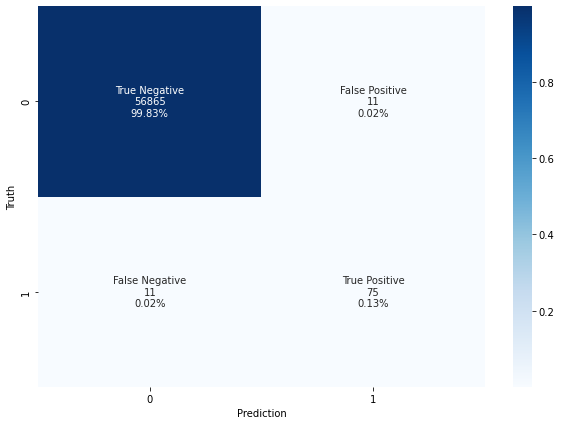

In [ ]:
rate_classifier(scaled_y_test, scaled_mlp_pred)

### Agglomerative Clustering

#### Non Standard Scaled

In [ ]:
agg_cluster = AgglomerativeClustering()

In [ ]:
agg_cluster = agg_cluster.fit(X_train)

In [ ]:
agg_cluster_pred = agg_cluster.predict(X_test)

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56876
           1       0.87      0.87      0.87        86

    accuracy                           1.00     56962
   macro avg       0.94      0.94      0.94     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy Score
 0.9996137776061234


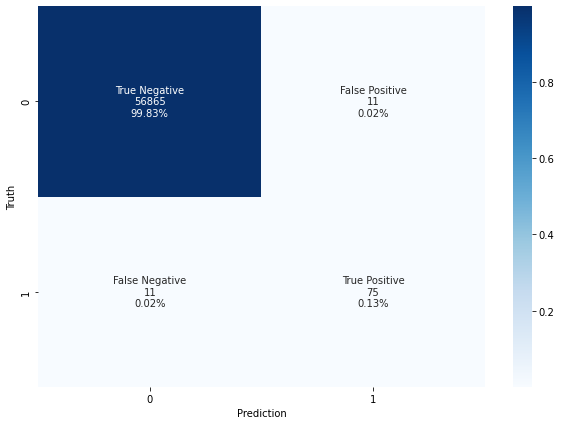

In [ ]:
rate_classifier(y_test, agg_cluster_pred)

#### Standard Scaled

In [ ]:
scaled_agg_cluster = AgglomerativeClustering()

In [ ]:
scaled_agg_cluster = scaled_agg_cluster.fit(scaled_X_train)

In [ ]:
scaled_agg_cluster_pred = scaled_agg_cluster.predict(scaled_X_test)

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56876
           1       0.87      0.87      0.87        86

    accuracy                           1.00     56962
   macro avg       0.94      0.94      0.94     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy Score
 0.9996137776061234


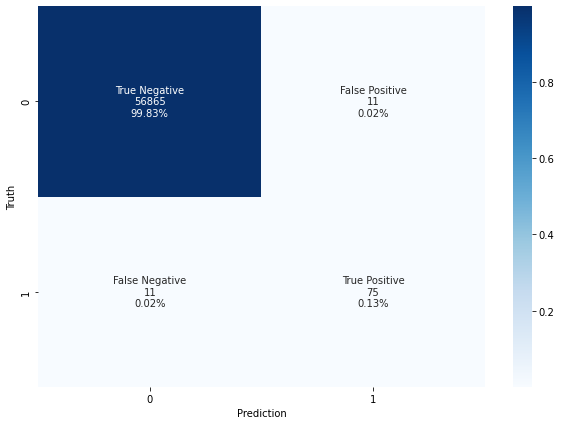

In [ ]:
rate_classifier(scaled_y_test, scaled_agg_cluster_pred)

### Credit Card MultiAttention Transformer Model

In [3]:
class Multi_Attention(nn.Module):
    def __init__(self, samp_model, num_heads):
        super(Multi_Attention, self).__init__()
        assert samp_model % num_heads == 0

        self.samp_model = samp_model
        self.num_heads = num_heads
        self.count = samp_model // num_heads

        self.Wq = nn.Linear(samp_model, samp_model)
        self.Wk = nn.Linear(samp_model, samp_model)
        self.Wv = nn.Linear(samp_model, samp_model)
        self.Wo = nn.Linear(samp_model, samp_model)

    def forward(self, x):
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)
        Q, K, V = self.split_heads(Q, K, V)

        # Scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(self.count)
        attention_weights = torch.softmax(scores, dim=-1)
        attended_values = torch.matmul(attention_weights, V)
        attended_values = self.combine_heads(attended_values)

        return self.Wo(attended_values).squeeze(1)

    def split_heads(self, Q, K, V):
        batch_size = Q.size(0)
        Q = Q.view(batch_size, -1, self.num_heads, self.count).transpose(1, 2)
        K = K.view(batch_size, -1, self.num_heads, self.count).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.count).transpose(1, 2)
        return Q, K, V

    def combine_heads(self, attended_values):
        batch_size = attended_values.size(0)
        return attended_values.transpose(1, 2).contiguous().view(batch_size, -1, self.samp_model)
    
class CreditCardFraudModel(nn.Module):
    def __init__(self, input_size, dropout_prob=0.5):
        super(CreditCardFraudModel, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.BatchNorm1d(128)
        )

        self.multi_attention = Multi_Attention(128, 2)
        self.layer2 = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.BatchNorm1d(64)
        )

        self.layer3 = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.BatchNorm1d(32),
        )
        self.output_layer = nn.Linear(32, 1)

    def forward(self, x):
        x = self.layer1(x)
        x = self.multi_attention(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.output_layer(x)
        return torch.sigmoid(x)
    
def train_and_evaluate(model, train_loader, test_loader, num_epochs, optimizer, scheduler, criterion, device):
    model.train()

    for epoch in range(num_epochs):
        running_loss_avg = 0.0
        alpha = 0.1
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), labels.float())
            loss.backward()
            optimizer.step()

            if scheduler:
                scheduler.step()

            running_loss_avg = alpha * loss.item() + (1 - alpha) * running_loss_avg

        # print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss / len(train_loader):.4f}")

    model.eval()
    y_pred, y_true = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            y_pred.extend(outputs.squeeze().tolist())
            y_true.extend(labels.tolist())

    y_pred = np.array(y_pred)
    y_pred_labels = (y_pred >= 0.5).astype(int)

    # This is for accuracy
    correct = np.sum(y_true == y_pred_labels)
    total = len(y_true)
    accuracy = correct / total

    precision = precision_score(y_true, y_pred_labels)
    recall = recall_score(y_true, y_pred_labels)
    f1 = f1_score(y_true, y_pred_labels)
    roc_auc = roc_auc_score(y_true, y_pred)
    
    conf_mat = confusion_matrix(y_true, y_pred_labels)

    return precision, recall, f1, roc_auc, accuracy, conf_mat, running_loss_avg


In [8]:
classifiers = classifiers = {
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=3),
    "SVM": SVC(),
    "C Adj SVM": SVC(C=100),
    "Gaussian Naive Bayes": GaussianNB(),
    "Bernoulli Naive Bayes": BernoulliNB(),
    "Logistic Regression": LogisticRegression(),
    "SGDClassifier": SGDClassifier(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Multi Layer Perceptron": MLPClassifier(),
    "Agglomerative Clustering": AgglomerativeClustering()
}

cpu


NameError: name 'X' is not defined

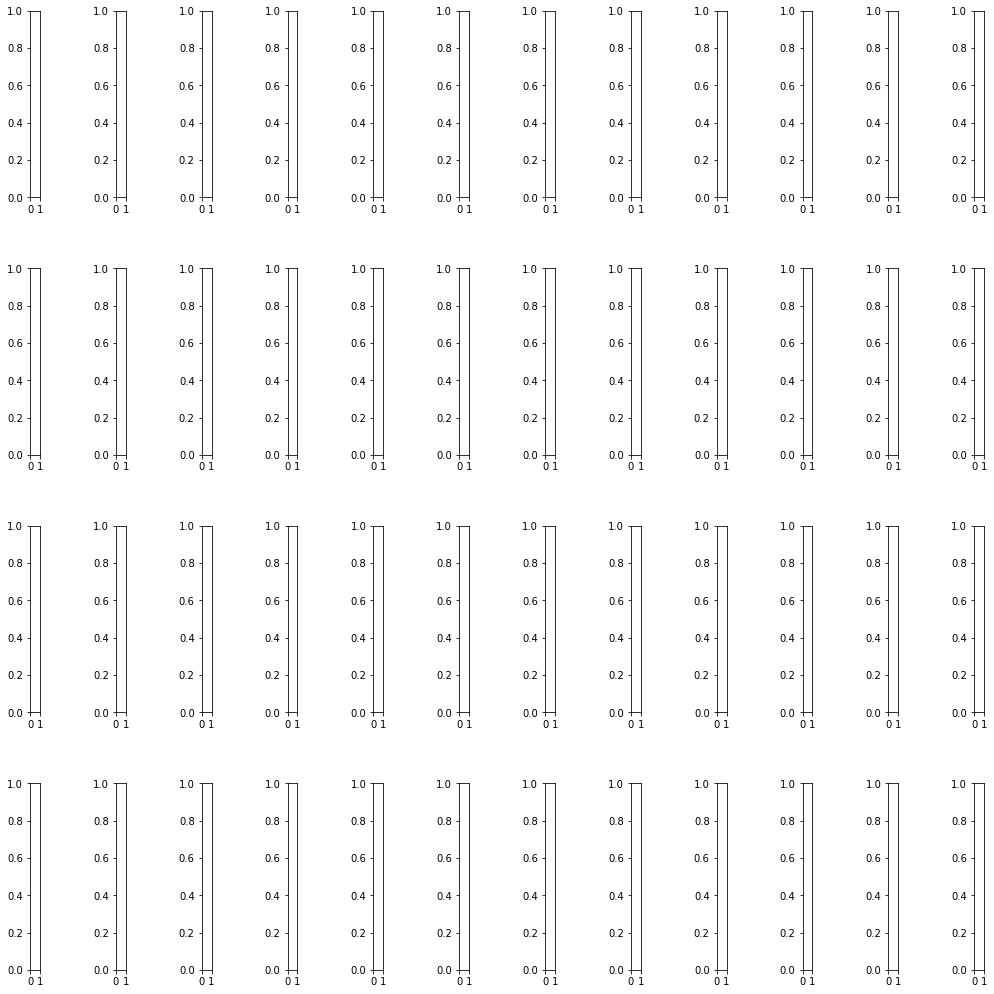

In [9]:
# Main program
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
#  device = torch.device("cuda")
skf = StratifiedKFold(n_splits=4)
criterion = nn.BCELoss()

metrics = {}

# for name in classifiers.keys():
#     metrics[name] = {"accuracy": [], "loss": []}
#     metrics["CreditCardFraudModel"] = {"accuracy": [], "loss": []}

num_splits = 4
num_classifiers = len(classifiers) + 1  # Add 1 for the CreditCardFraudModel
fig, axes = plt.subplots(num_splits, num_classifiers, figsize=(15, 15))
fig.tight_layout(pad=5.0)

counter=1

for train_index, test_index in skf.split(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

    col_idx = 0

    print("This is Split number: ",counter)

    print("\n===========================================================================\n")

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    metrics[name]["accuracy"].append(accuracy)

    conf_mat = confusion_matrix(y_test, y_pred)
    plot_confusion_matrix(axes[counter - 1, col_idx], conf_mat, counter, name)
    col_idx += 1

    print(f"{name}:")
    print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}, ROC-AUC: {roc_auc:.4f}\n")

    train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
    test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    model = CreditCardFraudModel(X_train.shape[1]).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)
    num_epochs = 15
    num_train_steps = num_epochs * len(train_loader)
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1 * num_train_steps), num_training_steps=num_train_steps)

    precision, recall, f1, roc_auc, accuracy, conf_mat, running_loss_avg = train_and_evaluate(model, train_loader, test_loader, num_epochs, optimizer, scheduler, criterion, device)
    

    metrics["CreditCardFraudModel"]["accuracy"].append(accuracy)
    running_loss_avg = running_loss_avg / len(train_loader)
    metrics["CreditCardFraudModel"]["loss"].append(running_loss_avg)

    plot_confusion_matrix(axes[counter - 1, col_idx], conf_mat, counter, "CreditCardFraudModel")
    
    print("\n===========================================================================\n")
    print("For the CreditCardFraudModel:")
    print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}, ROC-AUC: {roc_auc:.4f}")
    print("\n===========================================================================\n")
    
    counter+=1

print("\nAll the Confusion Matrices:")
plt.show()


#### Non Standard Scaled

In [ ]:
agg_cluster = Cred

In [ ]:
agg_cluster = agg_cluster.fit(X_train)

In [ ]:
agg_cluster_pred = agg_cluster.predict(X_test)

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56876
           1       0.87      0.87      0.87        86

    accuracy                           1.00     56962
   macro avg       0.94      0.94      0.94     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy Score
 0.9996137776061234


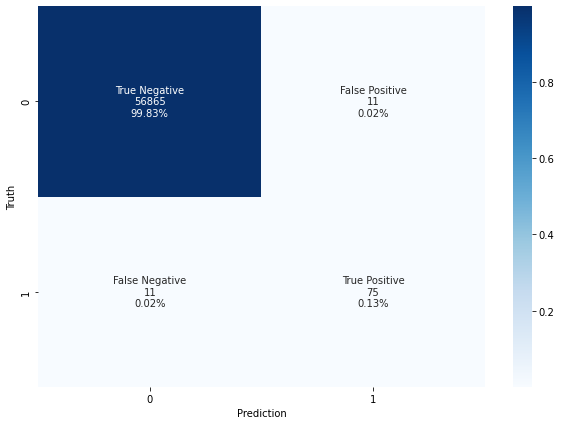

In [ ]:
rate_classifier(y_test, agg_cluster_pred)

#### Standard Scaled

In [ ]:
scaled_agg_cluster = AgglomerativeClustering()

In [ ]:
scaled_agg_cluster = scaled_agg_cluster.fit(scaled_X_train)

In [ ]:
scaled_agg_cluster_pred = scaled_agg_cluster.predict(scaled_X_test)

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56876
           1       0.87      0.87      0.87        86

    accuracy                           1.00     56962
   macro avg       0.94      0.94      0.94     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy Score
 0.9996137776061234


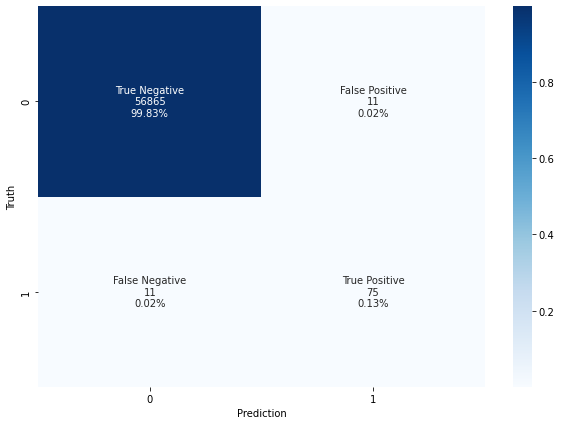

In [ ]:
rate_classifier(scaled_y_test, scaled_agg_cluster_pred)